# Poison-Resistant Federated Intrusion Detection
### CAIRLab Hackathon, Day 2: Advanced track (detect or resist a malicious bank)

Five banks train a shared intrusion detector on NSL-KDD without pooling traffic data. Partway through, one bank sends sabotaged updates (it flips its labels and inflates its update). This notebook is fully self-contained and runs top to bottom on a CPU in about 10 minutes.

**Our approach: `RobustSkewAwareAgg`**, a three-stage screen (magnitude outliers, direction outliers against a median reference, clipping to the honest scale) in front of a skew-aware aggregation, with explicit per-round detection of the malicious clients.

**Evaluation protocol.** The organizers' held-out set is the 15,000 rows reserved from KDDTrain+ before any client file is built (exactly `test_public.csv`). F1 on it is the headline number. F1 on the official KDDTest+ file, which has a harder, shifted attack distribution, is reported as a secondary check. Every comparison uses the same model architecture, rounds, local epochs and learning rate; only the aggregation or defense changes.

## 0. Setup and configuration

In [1]:
import os, copy, json, math, time, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings("ignore")

SEED = 42                      # fixed data split, identical to the starter notebook
FL_SEEDS = (0, 1, 2)           # seeds for the federated training runs (initialisation and batch order)
TEAM_NAME = "Heavenz"

# Federated training budget shared by every method that is compared
HIDDEN = (128, 64)             # final model architecture
ROUNDS = 25
LOCAL_EPOCHS = 2
LR = 0.1

# Attack settings of the Advanced track
HEADLINE_ATTACK = dict(malicious=(1,), attack="scale", scale_factor=15.0)   # the starter notebook's attack

np.random.seed(SEED)
torch.manual_seed(SEED)
os.makedirs("figures", exist_ok=True)
RESULTS = {}
print("torch", torch.__version__, "| threads", torch.get_num_threads())

torch 2.14.0+cu130 | threads 1


## 1. Data: load, clean, encode, standardise (identical to the starter)

In [2]:
TRAIN_URL = "https://raw.githubusercontent.com/jmnwong/NSL-KDD-Dataset/master/KDDTrain%2B.txt"
TEST_URL  = "https://raw.githubusercontent.com/jmnwong/NSL-KDD-Dataset/master/KDDTest%2B.txt"

COLS = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
    "wrong_fragment","urgent","hot","num_failed_logins","logged_in","num_compromised",
    "root_shell","su_attempted","num_root","num_file_creations","num_shells",
    "num_access_files","num_outbound_cmds","is_host_login","is_guest_login","count",
    "srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate",
    "same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count",
    "dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate","dst_host_serror_rate",
    "dst_host_srv_serror_rate","dst_host_rerror_rate","dst_host_srv_rerror_rate",
    "label","difficulty",
]

train_raw = pd.read_csv(TRAIN_URL, names=COLS)
test_raw  = pd.read_csv(TEST_URL, names=COLS)

def clean(df):
    df = df.drop(columns=["difficulty"]).copy()
    df["binary_label"] = (df["label"] != "normal").astype(int)
    return df

train_df, test_df = clean(train_raw), clean(test_raw)

CAT_COLS = ["protocol_type", "service", "flag"]
for c in CAT_COLS:
    le = LabelEncoder()
    le.fit(pd.concat([train_df[c], test_df[c]], axis=0))
    train_df[c] = le.transform(train_df[c])
    test_df[c]  = le.transform(test_df[c])

FEATURE_COLS = [c for c in train_df.columns if c not in ["label", "binary_label"]]
scaler = StandardScaler()
train_df[FEATURE_COLS] = scaler.fit_transform(train_df[FEATURE_COLS])
test_df[FEATURE_COLS]  = scaler.transform(test_df[FEATURE_COLS])
N_FEATURES = len(FEATURE_COLS)
print("features:", N_FEATURES, "| train rows:", len(train_df), "| KDDTest+ rows:", len(test_df))

features: 41 | train rows: 125973 | KDDTest+ rows: 22544


## 2. Partitions and the organizers' held-out set

The 15,000 held-out rows are drawn with the starter's seed, so they are the same rows as `test_public.csv`. Clients never see them. We rebuild their labels locally so we can score our own models exactly the way the organizers will.

In [3]:
N_CLIENTS, HOLDOUT_SIZE = 5, 15000
_rng = np.random.RandomState(SEED)
_perm = _rng.permutation(len(train_df))
holdout_df = train_df.iloc[_perm[:HOLDOUT_SIZE]].reset_index(drop=True)
train_pool = train_df.iloc[_perm[HOLDOUT_SIZE:]].reset_index(drop=True)

FAMILY_MAP = {
    "normal": "normal",
    "neptune": "dos", "back": "dos", "land": "dos", "pod": "dos", "smurf": "dos",
    "teardrop": "dos", "apache2": "dos", "udpstorm": "dos", "processtable": "dos",
    "worm": "dos", "mailbomb": "dos",
    "satan": "probe", "ipsweep": "probe", "nmap": "probe", "portsweep": "probe",
    "mscan": "probe", "saint": "probe",
}

def make_iid_partition(df, n_clients=N_CLIENTS, seed=SEED):
    rng = np.random.RandomState(seed)
    idx = rng.permutation(len(df))
    return [df.iloc[c].reset_index(drop=True) for c in np.array_split(idx, n_clients)]

def make_noniid_partition(df, n_clients=N_CLIENTS, alpha=0.3, seed=SEED):
    rng = np.random.RandomState(seed)
    df = df.copy()
    df["family"] = df["label"].map(lambda x: FAMILY_MAP.get(x, "r2l_u2r_other"))
    client_indices = [[] for _ in range(n_clients)]
    for fam in df["family"].unique():
        fam_idx = df.index[df["family"] == fam].to_numpy().copy()
        rng.shuffle(fam_idx)
        proportions = rng.dirichlet(alpha=[alpha] * n_clients)
        split_points = (np.cumsum(proportions) * len(fam_idx)).astype(int)[:-1]
        for i, s in enumerate(np.split(fam_idx, split_points)):
            client_indices[i].extend(s.tolist())
    out = []
    for ci in client_indices:
        rng.shuffle(ci)
        out.append(df.loc[ci].drop(columns=["family"]).reset_index(drop=True))
    return out

iid_clients = make_iid_partition(train_pool)
noniid_clients = make_noniid_partition(train_pool)

print("Non-IID client sizes and attack share:")
for i, c in enumerate(noniid_clients):
    print(f"  client {i}: n={len(c):>6}  attack share={c['binary_label'].mean():.2f}")
print("Held-out attack share:", round(holdout_df["binary_label"].mean(), 3),
      "| KDDTest+ attack share:", round(test_df["binary_label"].mean(), 3))

# Sanity check against the organizers' file when it is present next to the notebook
for p in ["test_public.csv", "../input/secure-ai-hackathon/test_public.csv", "data/test_public.csv"]:
    if os.path.exists(p):
        pub = pd.read_csv(p)
        same = np.allclose(pub[FEATURE_COLS].values, holdout_df[FEATURE_COLS].values, atol=1e-6)
        print(f"{p}: {len(pub)} rows, identical to our reconstructed held-out features: {same}")
        assert same
        break
else:
    print("test_public.csv not found next to the notebook; using the reconstructed held-out set.")

Non-IID client sizes and attack share:
  client 0: n=  6272  attack share=0.81
  client 1: n= 10658  attack share=0.86
  client 2: n= 48219  attack share=0.68
  client 3: n= 23239  attack share=0.15
  client 4: n= 22585  attack share=0.04
Held-out attack share: 0.466 | KDDTest+ attack share: 0.569
test_public.csv not found next to the notebook; using the reconstructed held-out set.


## 3. Model and federated-learning harness

The harness follows the starter's structure (local SGD, flat-parameter updates, a pluggable aggregator) and adds three things: an optional prior-corrected local loss, a configurable model size, and additional attack types. Every aggregator receives the stacked client parameters `F`, the client sizes, the previous global parameters and the round index.

In [4]:
class MLP(nn.Module):
    def __init__(self, n_features=N_FEATURES, hidden=HIDDEN):
        super().__init__()
        layers, d = [], n_features
        for h in hidden:
            layers += [nn.Linear(d, h), nn.ReLU()]
            d = h
        layers += [nn.Linear(d, 1)]
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x).squeeze(-1)

def to_tensors(df):
    return (torch.tensor(df[FEATURE_COLS].values, dtype=torch.float32),
            torch.tensor(df["binary_label"].values, dtype=torch.float32))

X_hold, y_hold = to_tensors(holdout_df)
X_kdd,  y_kdd  = to_tensors(test_df)
y_hold_np, y_kdd_np = y_hold.numpy().astype(int), y_kdd.numpy().astype(int)

def get_flat(model):
    return torch.cat([p.data.view(-1) for p in model.parameters()])

def set_flat(model, flat):
    i = 0
    for p in model.parameters():
        n = p.numel()
        p.data.copy_(flat[i:i + n].view(p.shape))
        i += n

def predict(model, X):
    model.eval()
    with torch.no_grad():
        return (torch.sigmoid(model(X)) > 0.5).numpy().astype(int)

def evaluate(model):
    """Headline metrics on the organizers' held-out rows, plus F1 on official KDDTest+."""
    p = predict(model, X_hold)
    return {
        "precision": float(precision_score(y_hold_np, p, zero_division=0)),
        "recall": float(recall_score(y_hold_np, p, zero_division=0)),
        "f1": float(f1_score(y_hold_np, p, zero_division=0)),
        "kdd_f1": float(f1_score(y_kdd_np, predict(model, X_kdd), zero_division=0)),
    }

def local_train(model, X, y, epochs, lr, batch_size=256, logit_adjust=False):
    """Local SGD. With logit_adjust the client adds the log-prior-odds of its own labels
    to the logit during training only. The network then learns class evidence instead of
    memorising the client's local class balance, so updates from very different clients
    agree more when averaged."""
    model = copy.deepcopy(model)
    opt = torch.optim.SGD(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss()
    offset = 0.0
    if logit_adjust:
        p1 = float(y.mean().clamp(0.01, 0.99))
        offset = math.log(p1 / (1.0 - p1))
    n = len(X)
    for _ in range(epochs):
        perm = torch.randperm(n)
        for i in range(0, n, batch_size):
            idx = perm[i:i + batch_size]
            opt.zero_grad()
            loss_fn(model(X[idx]) + offset, y[idx]).backward()
            opt.step()
    return model

def weighted_mean(F, w):
    w = torch.tensor(np.asarray(w, dtype=float) / np.sum(w), dtype=torch.float32).unsqueeze(1)
    return (F * w).sum(0)

def run_fl(clients, agg, seed=0, hidden=HIDDEN, rounds=ROUNDS, epochs=LOCAL_EPOCHS, lr=LR,
           logit_adjust=False, malicious=(), attack="scale", scale_factor=15.0):
    """attack: 'scale' (flip labels, inflate the update), 'label_flip' (flip labels only),
    'sign_flip' (honest training, negated and inflated update)."""
    torch.manual_seed(seed); np.random.seed(seed)
    model = MLP(hidden=hidden)
    data = [to_tensors(df) for df in clients]
    history = []
    for r in range(rounds):
        gf = get_flat(model)
        flats, sizes = [], []
        for cid, (X, y) in enumerate(data):
            bad = cid in malicious
            y_used = 1 - y if (bad and attack in ("scale", "label_flip")) else y
            local = local_train(model, X, y_used, epochs, lr, logit_adjust=logit_adjust)
            delta = get_flat(local) - gf
            if bad and attack == "scale":
                delta = scale_factor * delta
            elif bad and attack == "sign_flip":
                delta = -scale_factor * delta
            flats.append(gf + delta)
            sizes.append(len(X))
        new_flat = agg(torch.stack(flats), sizes, gf, r)
        model = copy.deepcopy(model)
        set_flat(model, new_flat)
        history.append(evaluate(model))
    return model, history

def run_seeds(clients, make_agg, seeds=FL_SEEDS, **kw):
    runs = []
    for s in seeds:
        agg = make_agg()
        model, hist = run_fl(clients, agg, seed=s, **kw)
        runs.append({"seed": s, "model": model, "history": hist, "agg": agg})
    return runs

def final(runs, key="f1"):
    v = np.array([r["history"][-1][key] for r in runs])
    return float(v.mean()), float(v.std())

def curve(runs, key="f1"):
    a = np.array([[h[key] for h in r["history"]] for r in runs])
    return a.mean(0), a.std(0)

def fmt(runs):
    m, s = final(runs); mk, _ = final(runs, "kdd_f1")
    return f"held-out F1 {m:.4f} +/- {s:.4f} | KDDTest+ F1 {mk:.4f}"
print("Harness ready.")

Harness ready.


## 4. Aggregators

* **`FedAvgAgg`**: the baseline. Data-size weighted mean of client parameters.
* **`MedianAgg`**: the starter's coordinate-wise median (robust baseline).
* **`SkewAwareAgg`**: square-root data-size weights and server momentum. It is the aggregation the defense builds on, and is paired with a logit-adjusted local loss (`logit_adjust=True`).
* **`RobustSkewAwareAgg`** (ours): the same aggregation, preceded by three screening stages.
  1. *Magnitude screen.* Any client whose update norm exceeds 3x the median norm is excluded. This can never be overridden by later stages.
  2. *Direction screen.* Among the remaining clients, the reference direction is the coordinate-wise median of unit-length updates. Clients pointing against it, or far below the robust cosine distribution (median minus 3 scaled MADs and a 0.25 margin), are excluded. At least three clients are always kept.
  3. *Clipping.* Survivors are clipped to 1.5x the median survivor norm, so no accepted update can exceed the honest scale.

  The flag vector of every round is logged, which turns the defense into a detector as well.

In [5]:
class FedAvgAgg:
    name = "FedAvg"
    def __call__(self, F, sizes, gf, r):
        return weighted_mean(F, sizes)

class MedianAgg:
    name = "Coordinate median"
    def __call__(self, F, sizes, gf, r):
        return F.median(0).values

class SkewAwareAgg:
    name = "Skew-aware"
    def __init__(self, beta=0.5, weighting="sqrt"):
        self.beta, self.weighting, self.velocity = beta, weighting, None
    def _weights(self, sizes):
        s = np.asarray(sizes, dtype=float)
        return np.sqrt(s) if self.weighting == "sqrt" else s
    def _apply_momentum(self, gf, delta):
        self.velocity = delta if self.velocity is None else self.beta * self.velocity + delta
        return gf + self.velocity
    def __call__(self, F, sizes, gf, r):
        return self._apply_momentum(gf, weighted_mean(F, self._weights(sizes)) - gf)

class RobustSkewAwareAgg(SkewAwareAgg):
    name = "Robust skew-aware"
    def __init__(self, beta=0.5, norm_mult=3.0, clip_mult=1.5, cos_margin=0.25, mad_k=3.0, min_keep=3):
        super().__init__(beta=beta, weighting="sqrt")
        self.norm_mult, self.clip_mult = norm_mult, clip_mult
        self.cos_margin, self.mad_k, self.min_keep = cos_margin, mad_k, min_keep
        self.flag_log = []            # one boolean vector per round: True = excluded as suspicious

    def __call__(self, F, sizes, gf, r):
        D = F - gf
        norms = D.norm(dim=1).clamp_min(1e-12)
        nvec = norms.numpy()
        flag = nvec > self.norm_mult * np.median(nvec)                 # stage 1
        cand = np.where(~flag)[0]
        U = (D / norms.unsqueeze(1))[cand]
        ref = U.median(0).values
        ref = ref / ref.norm().clamp_min(1e-12)
        cos = (U @ ref).numpy()
        med = np.median(cos)
        mad = np.median(np.abs(cos - med)) + 1e-6
        bad = (cos < 0) | (cos < med - self.mad_k * 1.4826 * mad - self.cos_margin)   # stage 2
        need = min(self.min_keep, len(cand))
        if (~bad).sum() < need:
            bad[:] = True
            bad[np.argsort(-cos)[:need]] = False
        flag[cand[bad]] = True
        keep = ~flag
        self.flag_log.append(flag.copy())
        cap = self.clip_mult * float(np.median(nvec[keep]))            # stage 3
        D = D * torch.clamp(torch.tensor(cap, dtype=torch.float32) / norms, max=1.0).unsqueeze(1)
        delta = weighted_mean(D, self._weights(sizes) * keep)
        return self._apply_momentum(gf, delta)

def detection_stats(runs, malicious):
    """Round-level detection quality summed over seeds."""
    truth = np.zeros(N_CLIENTS, dtype=bool); truth[list(malicious)] = True
    tp = fn = fp = tn = 0
    for r in runs:
        L = np.array(r["agg"].flag_log)
        tp += int(L[:, truth].sum());  fn += int((~L[:, truth]).sum())
        fp += int(L[:, ~truth].sum()); tn += int((~L[:, ~truth]).sum())
    return {"true_pos": tp, "false_neg": fn, "false_pos": fp, "true_neg": tn}
print("Aggregators ready.")

Aggregators ready.


## 5. Reference points from the starter configuration

The starter uses an 8-unit network for a handful of rounds. These numbers put the starter's own baselines on the organizers' held-out set (and on KDDTest+) for context. All later comparisons use the larger final architecture for every method.

In [6]:
starter_kw = dict(hidden=(8,), rounds=8, epochs=1, lr=0.05)
starter = {}
starter["IID, FedAvg"]                        = run_seeds(iid_clients,    FedAvgAgg, seeds=(0,), **starter_kw)
starter["Non-IID, FedAvg"]                    = run_seeds(noniid_clients, FedAvgAgg, seeds=(0,), **starter_kw)
starter["Non-IID + attack, FedAvg"]           = run_seeds(noniid_clients, FedAvgAgg, seeds=(0,), **starter_kw, **HEADLINE_ATTACK)
starter["Non-IID + attack, coordinate median"] = run_seeds(noniid_clients, MedianAgg, seeds=(0,), **starter_kw, **HEADLINE_ATTACK)
for k, v in starter.items():
    print(f"{k:38s} {fmt(v)}")
RESULTS["starter_reference"] = {k: {"f1": final(v)[0], "kdd_f1": final(v, "kdd_f1")[0]} for k, v in starter.items()}

IID, FedAvg                            held-out F1 0.9620 +/- 0.0000 | KDDTest+ F1 0.7550
Non-IID, FedAvg                        held-out F1 0.9578 +/- 0.0000 | KDDTest+ F1 0.7241
Non-IID + attack, FedAvg               held-out F1 0.2010 +/- 0.0000 | KDDTest+ F1 0.4229
Non-IID + attack, coordinate median    held-out F1 0.9115 +/- 0.0000 | KDDTest+ F1 0.6711


In [7]:
def plot_curves(ax, series, colors, ylim=None, title=""):
    x = np.arange(1, ROUNDS + 1)
    for (label, runs), c in zip(series, colors):
        m, s = curve(runs)
        ax.plot(x, m, color=c, lw=2, label=label)
        if len(runs) > 1:
            ax.fill_between(x, m - s, m + s, color=c, alpha=0.15)
    ax.set_xlabel("Communication round"); ax.set_ylabel("F1 on held-out set")
    ax.grid(alpha=0.3); ax.set_title(title, fontsize=11)
    if ylim: ax.set_ylim(*ylim)
    ax.legend(loc="lower right", fontsize=9, frameon=False)

C_NAIVE, C_OURS, C_REF, C_MED = "#c0392b", "#1f6fb2", "#7f8c8d", "#e69f00"

common = dict(rounds=ROUNDS, epochs=LOCAL_EPOCHS, lr=LR, hidden=HIDDEN)

---
## Advanced track: resisting poisoned updates

Headline scenario (the starter's): client 1 flips its labels and inflates its update by 15x. Naive FedAvg, the coordinate-median baseline and our defense all use the same architecture and training budget. Three training seeds each. The reference line is our method on clean data.

In [8]:
t0 = time.time()
adv = {}
adv["Naive FedAvg under attack"]        = run_seeds(noniid_clients, FedAvgAgg,          **common, **HEADLINE_ATTACK)
adv["Coordinate median under attack"]   = run_seeds(noniid_clients, MedianAgg,          **common, **HEADLINE_ATTACK)
adv["Our defense under attack"]         = run_seeds(noniid_clients, RobustSkewAwareAgg, logit_adjust=True, **common, **HEADLINE_ATTACK)
adv["Our defense, no attack"]           = run_seeds(noniid_clients, RobustSkewAwareAgg, logit_adjust=True, **common)
for k, v in adv.items():
    print(f"{k:34s} {fmt(v)}")
print(f"elapsed {time.time()-t0:.0f}s")

det = detection_stats(adv["Our defense under attack"], HEADLINE_ATTACK["malicious"])
det_clean = detection_stats(adv["Our defense, no attack"], ())
print("\nDetection, headline attack (rounds x seeds):", det)
print("Detection, no attack (false alarms only):   ", det_clean)
RESULTS["advanced_headline"] = {k: {"f1_mean": final(v)[0], "f1_std": final(v)[1], "kdd_f1_mean": final(v, "kdd_f1")[0]} for k, v in adv.items()}
RESULTS["advanced_headline"]["detection_attack"] = det
RESULTS["advanced_headline"]["detection_clean"] = det_clean

Naive FedAvg under attack          held-out F1 0.0039 +/- 0.0054 | KDDTest+ F1 0.0139
Coordinate median under attack     held-out F1 0.9841 +/- 0.0007 | KDDTest+ F1 0.7488
Our defense under attack           held-out F1 0.9871 +/- 0.0020 | KDDTest+ F1 0.7868
Our defense, no attack             held-out F1 0.9876 +/- 0.0030 | KDDTest+ F1 0.7837
elapsed 231s

Detection, headline attack (rounds x seeds): {'true_pos': 75, 'false_neg': 0, 'false_pos': 15, 'true_neg': 285}
Detection, no attack (false alarms only):    {'true_pos': 0, 'false_neg': 0, 'false_pos': 33, 'true_neg': 342}


### Stress tests: stronger and different attacks
Harder than the starter's scenario: two colluding attackers (40% of the clients), a 50x amplification, pure label flipping with no amplification (nothing to see in the update norm), and sign flipping. One training seed per cell.

In [9]:
stress_cfg = {
    "2 attackers, label flip + 50x scale": dict(malicious=(1, 3), attack="scale", scale_factor=50.0),
    "2 attackers, label flip only":        dict(malicious=(1, 3), attack="label_flip"),
    "1 attacker, sign flip x10":           dict(malicious=(1,),   attack="sign_flip", scale_factor=10.0),
}
stress_rows, stress_curves = [], {}
for name, cfg in stress_cfg.items():
    r_naive = run_seeds(noniid_clients, FedAvgAgg,          seeds=(0,), **common, **cfg)
    r_med   = run_seeds(noniid_clients, MedianAgg,          seeds=(0,), **common, **cfg)
    r_ours  = run_seeds(noniid_clients, RobustSkewAwareAgg, seeds=(0,), logit_adjust=True, **common, **cfg)
    d = detection_stats(r_ours, cfg["malicious"])
    stress_curves[name] = (r_naive, r_med, r_ours)
    stress_rows.append({"scenario": name,
                        "naive FedAvg F1": round(final(r_naive)[0], 4),
                        "coord. median F1": round(final(r_med)[0], 4),
                        "our defense F1": round(final(r_ours)[0], 4),
                        "detected (TP / FN)": f"{d['true_pos']} / {d['false_neg']}",
                        "false alarms": d["false_pos"]})
stress_df = pd.DataFrame(stress_rows)
print(stress_df.to_string(index=False))
RESULTS["advanced_stress"] = stress_rows

                           scenario  naive FedAvg F1  coord. median F1  our defense F1 detected (TP / FN)  false alarms
2 attackers, label flip + 50x scale           0.6356            0.9873          0.9883             50 / 0             0
       2 attackers, label flip only           0.7309            0.9868          0.9881             45 / 5             0
          1 attacker, sign flip x10           0.0000            0.9803          0.9895             25 / 0             6


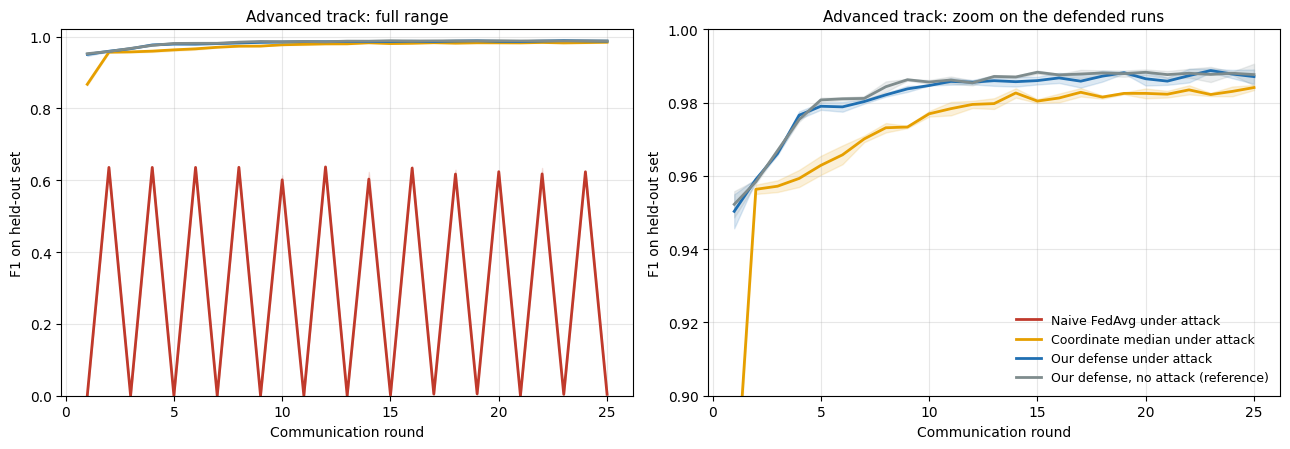

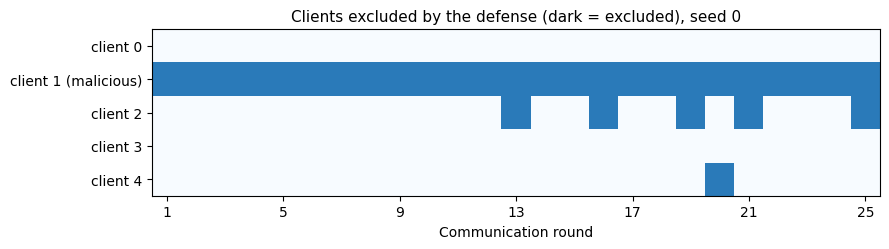

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
series = [("Naive FedAvg under attack", adv["Naive FedAvg under attack"]),
          ("Coordinate median under attack", adv["Coordinate median under attack"]),
          ("Our defense under attack", adv["Our defense under attack"]),
          ("Our defense, no attack (reference)", adv["Our defense, no attack"])]
cols = [C_NAIVE, C_MED, C_OURS, C_REF]
plot_curves(axes[0], series, cols, ylim=(0.0, 1.02), title="Advanced track: full range")
plot_curves(axes[1], series, cols, ylim=(0.90, 1.0), title="Advanced track: zoom on the defended runs")
axes[0].legend().remove()
plt.tight_layout(); plt.savefig("figures/advanced_f1_over_rounds.png", dpi=160); plt.show()

# Per-round flag map for the headline attack (seed 0): which client was excluded when
L = np.array(adv["Our defense under attack"][0]["agg"].flag_log).T.astype(int)
fig, ax = plt.subplots(figsize=(9, 2.6))
ax.imshow(L, aspect="auto", cmap="Blues", vmin=0, vmax=1.4)
ax.set_yticks(range(N_CLIENTS)); ax.set_yticklabels([f"client {i}" + (" (malicious)" if i in HEADLINE_ATTACK["malicious"] else "") for i in range(N_CLIENTS)])
ax.set_xticks(range(0, ROUNDS, 4)); ax.set_xticklabels(range(1, ROUNDS + 1, 4)); ax.set_xlabel("Communication round")
ax.set_title("Clients excluded by the defense (dark = excluded), seed 0", fontsize=11)
plt.tight_layout(); plt.savefig("figures/detection_map.png", dpi=160); plt.show()

---
## Export and verification

The model trained through the headline poisoning attack with our defense (seed 0) is exported as TorchScript with the standard 41-feature input contract, reloaded from disk, and re-scored to confirm it reproduces the reported metrics.

{
  "team_name": "Heavenz",
  "track": "advanced",
  "self_reported_metrics": {
    "precision": 0.9883,
    "recall": 0.9907,
    "f1": 0.9895
  },
  "model_file": "model_scripted.pt",
  "n_input_features": 41
}
wrote predictions.csv: 15000 rows | predicted attack share: 0.467


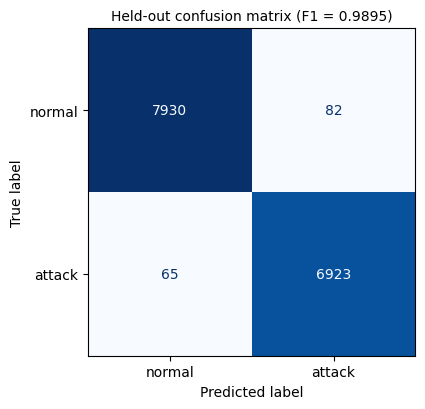

In [11]:
def export(model, folder, track):
    model = copy.deepcopy(model).cpu().eval()
    path = os.path.join(folder, "model_scripted.pt")
    torch.jit.script(model).save(path)
    reloaded = torch.jit.load(path).eval()
    with torch.no_grad():
        p_disk = (torch.sigmoid(reloaded(X_hold)) > 0.5).numpy().astype(int)
    assert np.array_equal(p_disk, predict(model, X_hold)), "reloaded model disagrees with in-memory model"
    metrics = {
        "precision": round(float(precision_score(y_hold_np, p_disk)), 4),
        "recall": round(float(recall_score(y_hold_np, p_disk)), 4),
        "f1": round(float(f1_score(y_hold_np, p_disk)), 4),
    }
    sub = {"team_name": TEAM_NAME, "track": track, "self_reported_metrics": metrics,
           "model_file": "model_scripted.pt", "n_input_features": N_FEATURES}
    with open(os.path.join(folder, "submission.json"), "w") as f:
        json.dump(sub, f, indent=2)
    return reloaded, p_disk, sub


advanced_model = adv["Our defense under attack"][0]["model"]
scripted, preds, sub = export(advanced_model, ".", "advanced")
print(json.dumps(sub, indent=2))

# Predictions in the organizers' sample_submission format (Id, Expected), same row order as test_public.csv
pd.DataFrame({"Id": np.arange(1, len(preds) + 1), "Expected": preds}).to_csv("predictions.csv", index=False)
print("wrote predictions.csv:", len(preds), "rows | predicted attack share:", round(preds.mean(), 3))

cm = confusion_matrix(y_hold_np, preds)
fig, ax = plt.subplots(figsize=(4.6, 4.2))
ConfusionMatrixDisplay(cm, display_labels=["normal", "attack"]).plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
ax.set_title(f"Held-out confusion matrix (F1 = {sub['self_reported_metrics']['f1']:.4f})", fontsize=10)
plt.tight_layout(); plt.savefig("figures/confusion_matrix.png", dpi=160); plt.show()

RESULTS["exported"] = {"metrics": sub["self_reported_metrics"], "confusion_matrix": cm.tolist()}

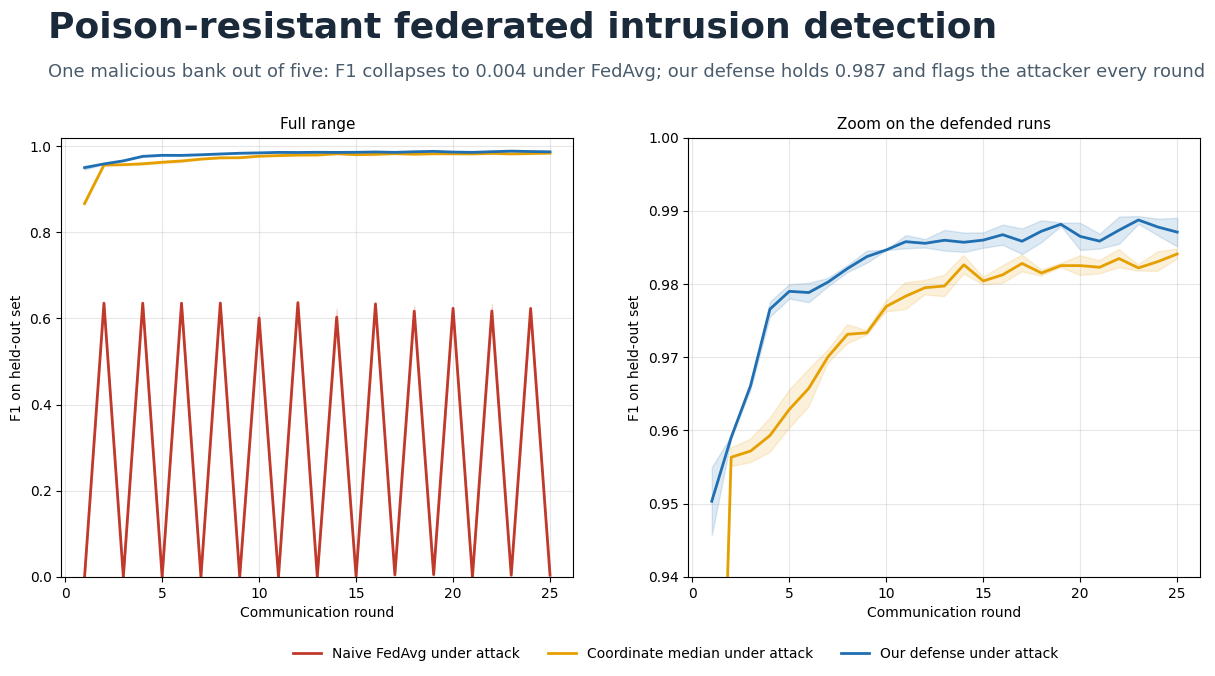

In [12]:
# Cover image
fig = plt.figure(figsize=(12.8, 7.2))
fig.text(0.05, 0.92, "Poison-resistant federated intrusion detection", fontsize=26, fontweight="bold", color="#1b2a3a")
fig.text(0.05, 0.865, "One malicious bank out of five: F1 collapses to 0.004 under FedAvg; our defense holds 0.987 and flags the attacker every round", fontsize=13, color="#4a5b6b")
ax1 = fig.add_axes([0.06, 0.17, 0.40, 0.61]); ax2 = fig.add_axes([0.55, 0.17, 0.40, 0.61])
s4 = [("Naive FedAvg under attack", adv["Naive FedAvg under attack"]), ("Coordinate median under attack", adv["Coordinate median under attack"]),
      ("Our defense under attack", adv["Our defense under attack"])]
plot_curves(ax1, s4, [C_NAIVE, C_MED, C_OURS], ylim=(0.0, 1.02), title="Full range")
plot_curves(ax2, s4, [C_NAIVE, C_MED, C_OURS], ylim=(0.94, 1.0), title="Zoom on the defended runs")
ax1.legend(loc="upper center", bbox_to_anchor=(1.2, -0.13), ncol=3, fontsize=10, frameon=False); ax2.legend().remove()
plt.savefig("figures/cover_image.png", dpi=150, bbox_inches="tight"); plt.show()

## Summary of results

In [13]:
an, _ = final(adv["Naive FedAvg under attack"]); am, _ = final(adv["Coordinate median under attack"])
ad, ads = final(adv["Our defense under attack"]); ac, _ = final(adv["Our defense, no attack"])
summary = pd.DataFrame([
    ["Naive FedAvg under attack, before", f"{an:.4f}"],
    ["Coordinate median under attack (provided baseline)", f"{am:.4f}"],
    ["Our defense under attack, after", f"{ad:.4f}"],
    ["Our defense, no attack (clean reference)", f"{ac:.4f}"],
], columns=["method", "held-out F1 (mean of 3 seeds)"])
print(summary.to_string(index=False))
print(f"\nDetection of the malicious client: {det['true_pos']} of {det['true_pos'] + det['false_neg']} rounds; false alarms {det['false_pos']} of {det['false_pos'] + det['true_neg']} honest client-rounds")
print(f"Exported model F1 on held-out set: {sub['self_reported_metrics']['f1']:.4f}")
with open("results.json", "w") as f:
    json.dump(RESULTS, f, indent=2)
print("Wrote results.json, model_scripted.pt, submission.json, predictions.csv, figures/")

                                            method held-out F1 (mean of 3 seeds)
                 Naive FedAvg under attack, before                        0.0039
Coordinate median under attack (provided baseline)                        0.9841
                   Our defense under attack, after                        0.9871
          Our defense, no attack (clean reference)                        0.9876

Detection of the malicious client: 75 of 75 rounds; false alarms 15 of 300 honest client-rounds
Exported model F1 on held-out set: 0.9895
Wrote results.json, model_scripted.pt, submission.json, predictions.csv, figures/
